# Multi-Agent Framework Comparison — Analysis Notebook

This notebook loads results from a **framework sweep** — runs of the same test
suite across several agentic architectures (`one_agent`, `two_agent`, `three_agent`)
and multiple LLM models — and produces a comprehensive set of plots to:

1. **Decide which framework is best** overall and per-model
2. **Diagnose failure modes** — which tests, which RAG entries, which failure types
3. **Benchmark efficiency** — latency, token usage, cost, LLM/tool call counts
4. **Understand RAG impact** across frameworks and models

This notebook shares its data loading, statistics, and plotting style with
`agent_eval_master_analysis.ipynb` and `optimal_config_comparisons.ipynb` via
**`agent_eval_core_master.py`** — the single place that defines how data is
parsed, how confidence intervals are computed, and what a figure looks like.
Every chart that aggregates over multiple test runs (i.e. every bar chart, plus
the scatter "efficiency frontiers") shows a 95% confidence interval, computed
from the spread of the individual test results that go into it — not by
re-running the suite multiple times, but by treating the population of
individual benchmark-test executions as the sample whose variability we want
to see.

### Sections
1. Setup & Data Loading
2. Preprocessing & Config Labels
3. **Pass-Rate Bar Chart** — Framework × Model
4. Per-Test Pass Rate Heatmap
5. Failure Type Breakdown
6. Latency Analysis
7. Token Usage Analysis
8. Cost & Efficiency Frontier Analysis
9. LLM & Tool Call Counts
10. RAG Retrieval Impact
11. Framework Diagnostic Summary (Radar)
12. Per-Test Regression — Which tests drive failures?
13. Summary Decision Table

> **Set `FRAMEWORK_SWEEP_ROOT`** in the first code cell to your results directory.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from scipy import stats

import agent_eval_core_master_updated as ae

warnings.filterwarnings("ignore", category=FutureWarning)

# ONE style call shared by every notebook (colors, spines, grid, fonts).
# `extra_rc` only tweaks figure-specific defaults (bigger base font here,
# since this notebook draws full-width single figures rather than the dense
# small-multiples used elsewhere) -- the underlying palette/style is shared.
ae.set_publication_style(extra_rc={"figure.dpi": 130, "axes.titlesize": 13, "font.size": 10})

# -- EDIT THIS PATH -----------------------------------------------------------
# Point this at a directory containing your suite_*.json / regression_data_*.jsonl
# result files. Frameworks are no longer determined by subdirectory layout --
# point this at wherever your results actually live (one flat folder, nested
# sweep folders, results from different architectures mixed together, etc.)
# and each result's own `cfg_graph_topology` (from its config snapshot) decides
# which architecture it belongs to. Older suites that predate that field are
# automatically treated as `ae.DEFAULT_GRAPH_TOPOLOGY` ("two_agent").
FRAMEWORK_SWEEP_ROOT = Path("./sweep_results/surrogate_modeling_benchmark_suites/framework_sweep_results/")
PLOT_DIR = Path("./figures")
# -------------------------------------------------------------------------------
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Framework names/labels/colors are defined ONCE in agent_eval_core_master so
# every notebook that compares architectures uses the same names and colors.
# FRAMEWORK_ORDER is just the preferred display order for the well-known
# architectures -- any other cfg_graph_topology value found in the data (e.g.
# a new "four_agent" architecture) is still loaded and plotted, it just sorts
# after these. Add an entry to FRAMEWORK_LABELS/FRAMEWORK_COLORS below if you
# want a nicer label/color for it than the raw topology string.
FRAMEWORK_DIRS = list(ae.FRAMEWORK_ORDER)         # ["one_agent", "two_agent", "three_agent"]
FRAMEWORK_LABELS = dict(ae.FRAMEWORK_LABELS)
FRAMEWORK_COLORS = dict(ae.FRAMEWORK_COLORS)
FRAMEWORK_HATCHES = dict(ae.FRAMEWORK_HATCHES)
FRAMEWORK_MARKER_HATCHES = dict(ae.FRAMEWORK_MARKER_HATCHES)
FRAMEWORK_LINESTYLES = dict(ae.FRAMEWORK_LINESTYLES)
PASS_COLOR = ae.STATUS_COLORS["passed"]
FAIL_COLOR = ae.STATUS_COLORS["failed"]

print(f"Framework sweep root : {FRAMEWORK_SWEEP_ROOT.resolve()}")
print(f"Exists               : {FRAMEWORK_SWEEP_ROOT.exists()}")


Framework sweep root : C:\Users\M6NJOHNS\OneDrive - Carl Zeiss AG\Documents\September Platform\XRM\september_testing_results\sweep_results\surrogate_modeling_benchmark_suites\framework_sweep_results
Exists               : True


## 1 -- Data Loading

`ae.load_framework_sweep` wraps the same `suite_*.json` / `regression_data_*.jsonl` parser used by every other notebook (`load_evaluation_data`), pointed at `FRAMEWORK_SWEEP_ROOT` as a whole (searched recursively), and tags every row with `framework` / `framework_label` columns **read from that result's own `cfg_graph_topology` config field** -- not from which subdirectory the file happened to live in. It also returns the per-retrieval-event RAG detail table (`rag_events`) needed for the agent-level RAG latency chart in Section 10 -- no separate bespoke loader needed.

Results from older suites that predate `cfg_graph_topology` are not dropped -- `flatten_config_snapshot` backfills them with `ae.DEFAULT_GRAPH_TOPOLOGY` ("two_agent"), which was the architecture in use before the field existed.

If one of the well-known architectures in `FRAMEWORK_DIRS` has zero matching rows anywhere under the root, it's reported in `missing` rather than silently fabricating data; downstream cells degrade gracefully (fewer bars/panels) if a framework has no data.

In [2]:
loaded = ae.load_framework_sweep(FRAMEWORK_SWEEP_ROOT, labels=FRAMEWORK_LABELS, expected_frameworks=FRAMEWORK_DIRS)
df = loaded["runs"]
rag_events = loaded["rag_events"]   # one row per retrieved RAG entry per retrieval event
missing = loaded["missing"]

if missing:
    print(f"⚠  No data found for: {missing}")

if df.empty:
    print("\n⚠  No data found under FRAMEWORK_SWEEP_ROOT -- check the path in the setup cell.")
else:
    print(f"✅ Loaded {len(df)} test results across {df['framework'].nunique()} framework(s) "
          f"and {df['cfg_llm_model'].nunique()} model(s), from "
          f"{df['source_file'].nunique() if 'source_file' in df.columns else '?'} source file(s).")
    print(f"   RAG retrieval-event rows: {len(rag_events)}")


✅ Loaded 540 test results across 3 framework(s) and 5 model(s), from 36 source file(s).
   RAG retrieval-event rows: 8357


## 2 -- Preprocessing & Config Labels

`ae.load_framework_sweep` already runs every row through the canonical `clean_run_table` (numeric coercion, `duration_s`, `passed_int`, list-column normalization, `config_label`), so this section only fixes display ordering. Any architecture found in the data that isn't in `FRAMEWORK_DIRS` (e.g. a new topology added after this notebook was last edited) is appended to the ordering automatically rather than being dropped.

In [3]:
# Preferred order first (well-known architectures), then any other topology
# value present in the data that wasn't anticipated -- so new architectures
# show up instead of silently vanishing from every chart below.
present_frameworks = [f for f in df["framework"].dropna().unique().tolist()]
extra_frameworks = sorted(f for f in present_frameworks if f not in FRAMEWORK_DIRS)
FULL_FRAMEWORK_ORDER = FRAMEWORK_DIRS + extra_frameworks

df["framework"] = pd.Categorical(df["framework"], categories=FULL_FRAMEWORK_ORDER, ordered=True)
FW_PRESENT = [f for f in FULL_FRAMEWORK_ORDER if f in set(df["framework"].dropna())]
FW_ORDER = FW_PRESENT
MODELS_PRESENT = sorted(df["cfg_llm_model"].dropna().unique().tolist())

# Shared color/marker maps so models get the same color in every chart below.
MODEL_COLORS = ae.get_categorical_colors(MODELS_PRESENT, palette=ae.BLUE_CMAP)
MODEL_HATCHES = ae.get_hatch_map(MODELS_PRESENT)
MODEL_MARKERS = ae.get_marker_map(MODELS_PRESENT)

if extra_frameworks:
    print(f"ℹ  Found architecture(s) not in FRAMEWORK_DIRS: {extra_frameworks} "
          f"(add labels/colors for them in the setup cell if you want nicer display names)")
print(f"Frameworks : {FW_ORDER}")
print(f"Models     : {MODELS_PRESENT}")
print(f"Tests      : {df['test_id'].nunique()} unique ({sorted(df['test_id'].unique())[:6]}...)")
print(f"Total rows : {len(df)}")


Frameworks : ['one_agent', 'two_agent', 'three_agent']
Models     : ['claude-3-7-sonnet', 'claude-opus-45', 'claude-sonnet-4', 'gpt-41', 'gpt-51']
Tests      : 15 unique (['geom_001', 'geom_002', 'reg_003', 'wf_analyze_001', 'wf_analyze_002', 'wf_analyze_003']...)
Total rows : 540


## 3 — Pass-Rate Bar Chart: Framework × Model

Primary decision chart. Each framework is a first-order group; bars within each group are colored by LLM model. Error bars are **95% Wilson confidence intervals** on the pass rate (the appropriate interval for a binomial proportion — exact `n_passed / n_tests`, not a normal approximation), computed by `ae.summarize_with_ci(..., kind="wilson")`. Dashed lines mark each framework's overall average across models.

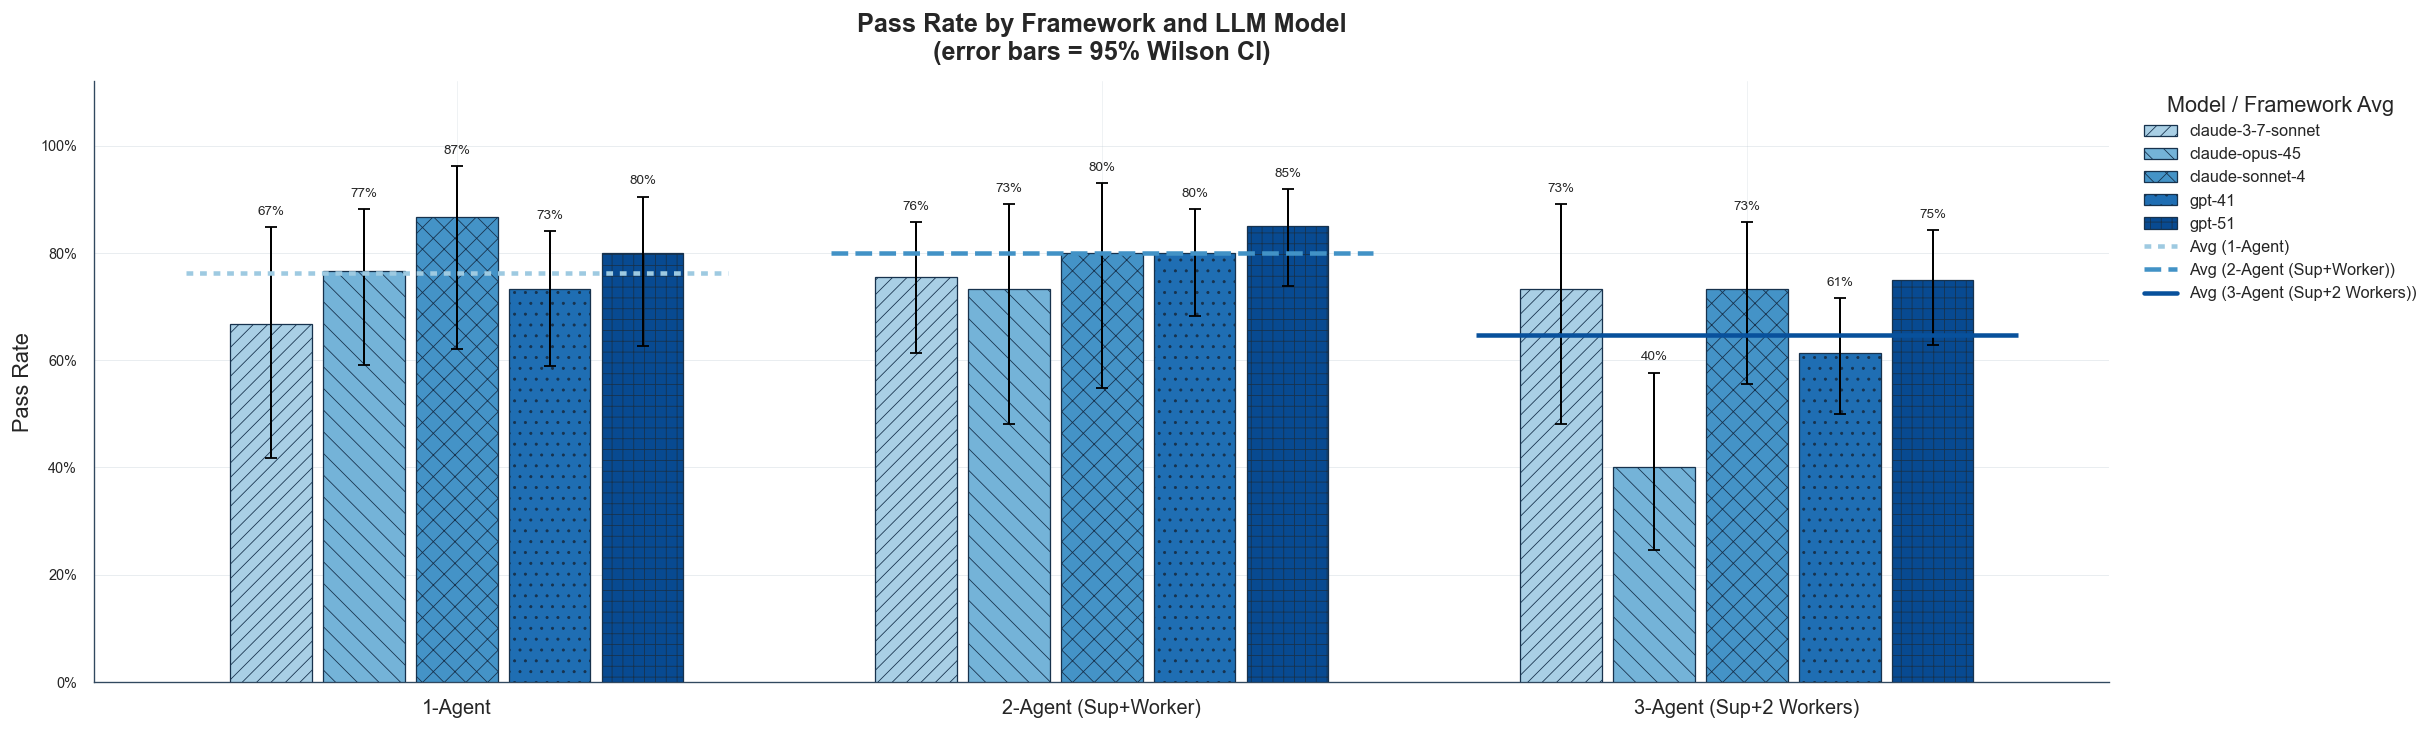

Saved: figures/pass_rate_framework_model.(png|pdf)


In [4]:
pass_summary = ae.summarize_with_ci(df, ["framework", "cfg_llm_model"], "passed_int", kind="wilson")
fw_mean = ae.summarize_with_ci(df, ["framework"], "passed_int", kind="wilson").set_index("framework")["estimate"]

fig, ax = plt.subplots(figsize=(max(10, len(FW_ORDER) * len(MODELS_PRESENT) * 1.2 + 2), 6))
ae.plot_grouped_bars(
    ax, pass_summary, category_col="framework", group_col="cfg_llm_model",
    category_order=FW_ORDER, group_order=MODELS_PRESENT, color_map=MODEL_COLORS, hatch_map=MODEL_HATCHES,
    bar_label_fmt=lambda v: f"{v:.0%}", legend_title="Model",
)
for i, fw in enumerate(FW_ORDER):
    if fw in fw_mean.index:
        ax.hlines(fw_mean[fw], i - 0.42, i + 0.42, colors=FRAMEWORK_COLORS.get(fw, "gray"),
                  linewidths=2.5, linestyles=FRAMEWORK_LINESTYLES.get(fw, "--"), zorder=5)

ax.set_xticklabels([FRAMEWORK_LABELS.get(fw, fw) for fw in FW_ORDER], fontsize=11)
ax.set_ylabel("Pass Rate", fontsize=12)
ax.set_title("Pass Rate by Framework and LLM Model\n(error bars = 95% Wilson CI)", fontsize=14, pad=12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.12)

dash_patches = [plt.Line2D([0], [0], color=FRAMEWORK_COLORS.get(fw, ae.BLUE_EDGE_COLOR),
                               linestyle=FRAMEWORK_LINESTYLES.get(fw, "--"), linewidth=2.5,
                               label=f"Avg ({FRAMEWORK_LABELS.get(fw, fw)})")
                for fw in FW_ORDER if fw in fw_mean.index]
model_handles = ae.make_legend_patches(MODELS_PRESENT, color_map=MODEL_COLORS, hatch_map=MODEL_HATCHES)
ax.legend(handles=model_handles + dash_patches, title="Model / Framework Avg",
          bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9, frameon=False)

ae.save_figure(fig, "pass_rate_framework_model", PLOT_DIR)
plt.show()
print(f"Saved: {PLOT_DIR}/pass_rate_framework_model.(png|pdf)")


## 4 — Per-Test Pass-Rate Heatmap

Shows which specific tests drive differences between frameworks (rows) and models (columns within each framework). Each cell is a point estimate over the runs of that test/framework/model combination; a heatmap cannot show an interval per cell without becoming unreadable, so cells are annotated with their sample size `n` instead — small `n` cells should be read with more caution than large ones.

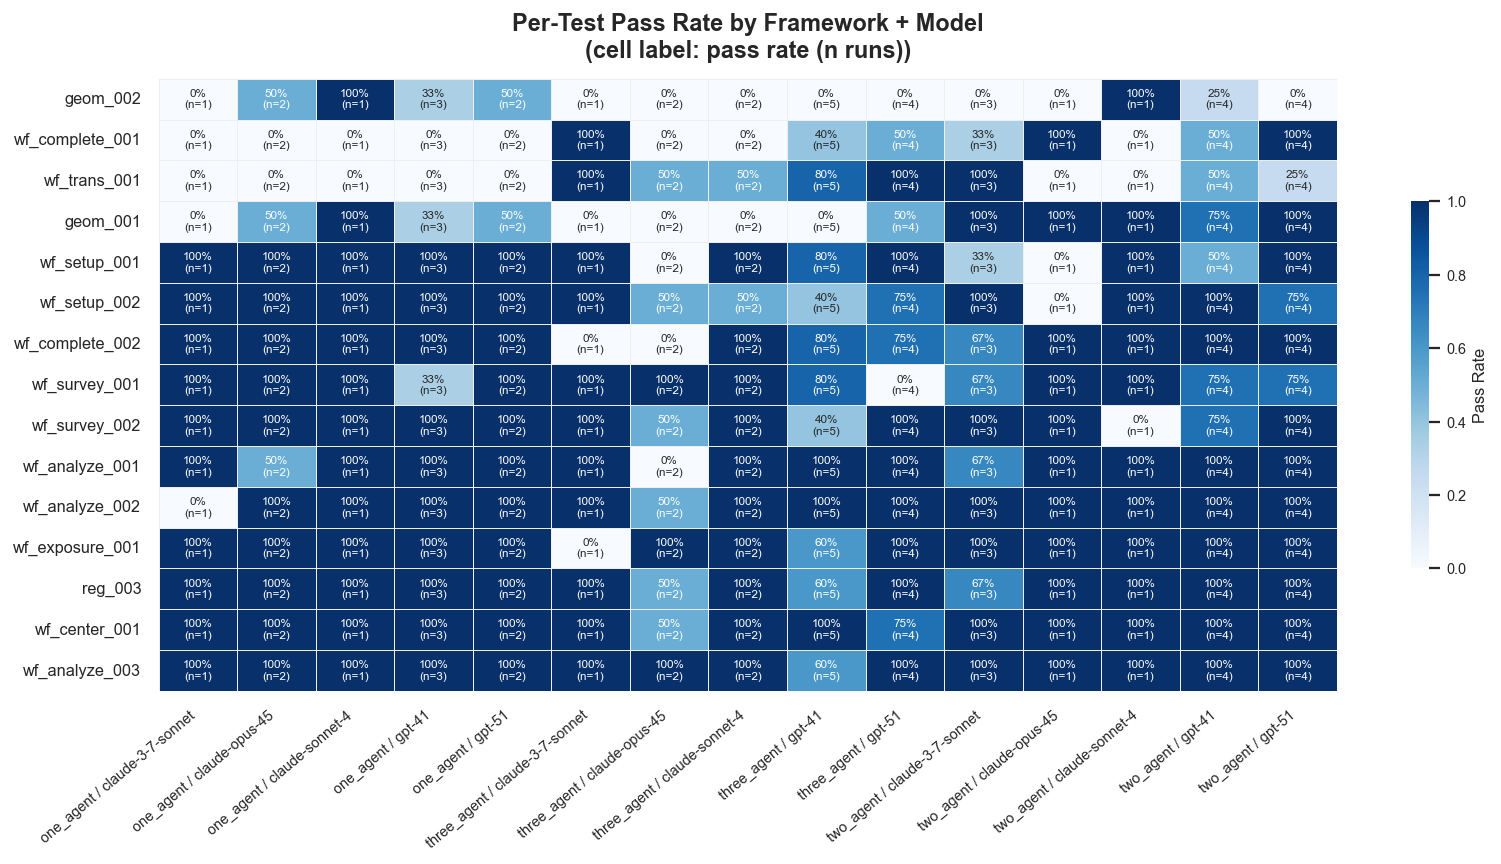

Saved: figures/pass_rate_heatmap.(png|pdf)


In [5]:
heat = (
    df.groupby(["test_id", "framework", "cfg_llm_model"])["passed_int"]
    .agg(pass_rate="mean", n="count")
    .reset_index()
)
heat["fw_model"] = heat["framework"].astype(str) + " / " + heat["cfg_llm_model"]

pivot = heat.pivot_table(index="test_id", columns="fw_model", values="pass_rate", aggfunc="mean")
n_pivot = heat.pivot_table(index="test_id", columns="fw_model", values="n", aggfunc="sum")
pivot = pivot.loc[pivot.mean(axis=1).sort_values().index]
n_pivot = n_pivot.loc[pivot.index]

import seaborn as sns
fig, ax = plt.subplots(figsize=(max(12, pivot.shape[1] * 0.85), max(5, pivot.shape[0] * 0.45)))
annot = pd.DataFrame(
    [[f"{v:.0%}\n(n={int(n_pivot.iloc[i, j])})" if pd.notna(v) else "" for j, v in enumerate(row)]
     for i, row in enumerate(pivot.values)],
    index=pivot.index, columns=pivot.columns,
)
sns.heatmap(pivot, cmap=ae.BLUE_CMAP, vmin=0, vmax=1, ax=ax, annot=annot, fmt="",
            linewidths=0.5, linecolor="#eeeeee", cbar_kws={"label": "Pass Rate", "shrink": 0.6},
            annot_kws={"fontsize": 6.5})
ax.set_title("Per-Test Pass Rate by Framework + Model\n(cell label: pass rate (n runs))", pad=12)
ax.set_xlabel(""); ax.set_ylabel("")
plt.xticks(rotation=40, ha="right", fontsize=8)
plt.yticks(fontsize=9)
fig.tight_layout()
ae.save_figure(fig, "pass_rate_heatmap", PLOT_DIR)
plt.show()
print(f"Saved: {PLOT_DIR}/pass_rate_heatmap.(png|pdf)")


## 5 — Failure Type Breakdown by Framework

Helps diagnose *why* a framework is failing — different failure signatures point to different architectural problems. Bars show the **rate** of each failure type as a fraction of all tests run in that framework (not a raw count, so frameworks with different total run counts are comparable), with 95% Wilson CIs.

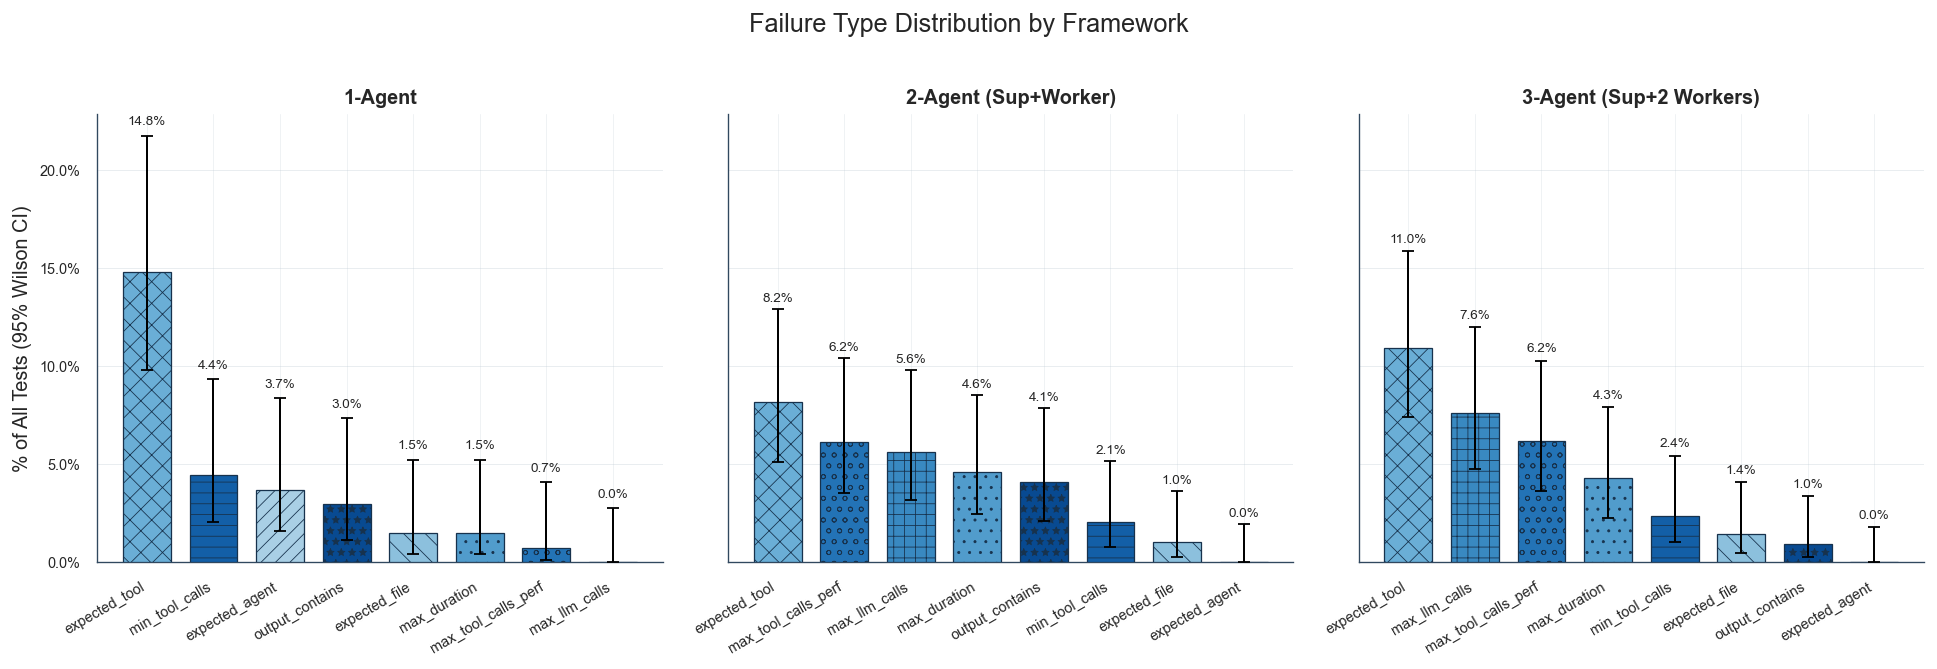

Saved: figures/failure_types_by_framework.(png|pdf)


In [6]:
if "failure_types" in df.columns:
    fail_df = df[~df["passed"]].copy()
    fail_exp = fail_df.explode("failure_types").dropna(subset=["failure_types"])
    fail_exp = fail_exp[fail_exp["failure_types"].astype(str).str.strip() != ""]

    if len(fail_exp) == 0:
        print("No failure type data found — skipping")
    else:
        # One row per (run, failure_type) so a rate-with-CI can be computed against
        # the FULL per-framework run count (tests with no listed failure type count
        # as 0 for every type, which is what makes the rate, and its CI, meaningful).
        all_types = sorted(fail_exp["failure_types"].unique())
        # Build a per-(run, failure_type) indicator (1 if that run has that failure
        # type, else 0) against the FULL per-framework run count -- this is what
        # makes "rate" (and its Wilson CI) well-defined, rather than just counting
        # occurrences among failures alone.
        ind_rows = []
        for fw in FW_ORDER:
            fw_keys = df.loc[df["framework"] == fw, "run_key"]
            fail_keys_by_type = {ft: set(fail_exp.loc[(fail_exp["framework"] == fw) & (fail_exp["failure_types"] == ft), "run_key"])
                                  for ft in all_types}
            for rk in fw_keys:
                for ft in all_types:
                    ind_rows.append({"framework": fw, "failure_types": ft, "indicator": int(rk in fail_keys_by_type[ft])})
        ind_df = pd.DataFrame(ind_rows)

        ft_palette = ae.get_categorical_colors(all_types, palette=ae.BLUE_CMAP)
        fig, axes = plt.subplots(1, len(FW_ORDER), figsize=(5 * len(FW_ORDER), 5), sharey=True)
        if len(FW_ORDER) == 1:
            axes = [axes]
        for ax, fw in zip(axes, FW_ORDER):
            sub = ind_df[ind_df["framework"] == fw]
            ci = ae.summarize_with_ci(sub, ["failure_types"], "indicator", kind="wilson")
            ci = ci.sort_values("estimate", ascending=False)
            if ci.empty or ci["estimate"].fillna(0).sum() == 0:
                ax.text(0.5, 0.5, "No failures", ha="center", va="center", transform=ax.transAxes, fontsize=11, color="gray")
            else:
                ae.plot_grouped_bars(ax, ci, category_col="failure_types", color_map=ft_palette,
                                      category_order=ci["failure_types"].tolist(),
                                      bar_label_fmt=lambda v: f"{v:.1%}", show_legend=False, rotate_xticks=30)
                ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
            ax.set_title(FRAMEWORK_LABELS.get(fw, fw), fontsize=11)
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelsize=8)
        axes[0].set_ylabel("% of All Tests (95% Wilson CI)", fontsize=11)
        fig.suptitle("Failure Type Distribution by Framework", fontsize=14, y=1.02)
        fig.tight_layout()
        ae.save_figure(fig, "failure_types_by_framework", PLOT_DIR)
        plt.show()
        print(f"Saved: {PLOT_DIR}/failure_types_by_framework.(png|pdf)")


## 6 — Latency Analysis

Box plot (per-framework, full distribution) plus a grouped bar of **mean** duration per framework × model with 95% CI (normal approximation on the mean, via `ae.summarize_with_ci(..., kind="mean")`) — the box plot shows spread, the bar+CI shows whether the *means* are distinguishable.

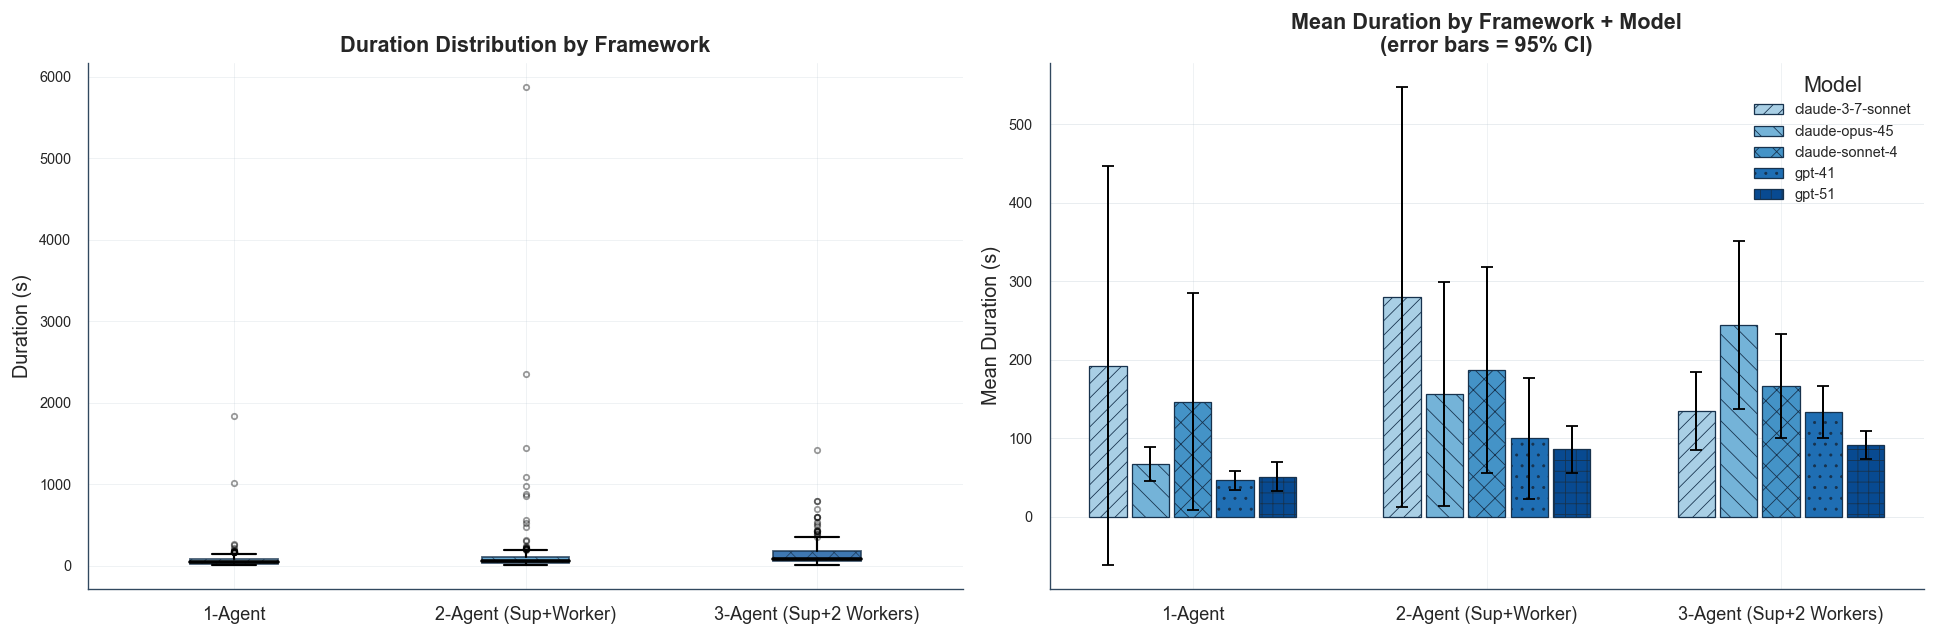

Saved: figures/latency_analysis.(png|pdf)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
fw_data = [df.loc[df["framework"] == fw, "duration_s"].dropna() for fw in FW_ORDER]
bp = ax.boxplot(fw_data, patch_artist=True, medianprops={"color": "black", "linewidth": 2},
                whiskerprops={"linewidth": 1.2}, capprops={"linewidth": 1.2},
                flierprops={"marker": "o", "markersize": 3, "alpha": 0.4})
for patch, fw in zip(bp["boxes"], FW_ORDER):
    patch.set_facecolor(FRAMEWORK_COLORS.get(fw, "#9ECAE1"))
    patch.set_edgecolor(ae.BLUE_EDGE_COLOR)
    patch.set_hatch(FRAMEWORK_HATCHES.get(fw, ""))
    patch.set_alpha(0.78)
ax.set_xticks(range(1, len(FW_ORDER) + 1))
ax.set_xticklabels([FRAMEWORK_LABELS.get(fw, fw) for fw in FW_ORDER], fontsize=10)
ax.set_ylabel("Duration (s)", fontsize=11)
ax.set_title("Duration Distribution by Framework", fontsize=12)

dur_summary = ae.summarize_with_ci(df, ["framework", "cfg_llm_model"], "duration_s", kind="mean")
ae.plot_grouped_bars(
    axes[1], dur_summary, category_col="framework", group_col="cfg_llm_model",
    category_order=FW_ORDER, group_order=MODELS_PRESENT, color_map=MODEL_COLORS, hatch_map=MODEL_HATCHES,
    bar_label_fmt=None, legend_title="Model",
)
axes[1].set_xticklabels([FRAMEWORK_LABELS.get(fw, fw) for fw in FW_ORDER], fontsize=10)
axes[1].set_ylabel("Mean Duration (s)", fontsize=11)
axes[1].set_title("Mean Duration by Framework + Model\n(error bars = 95% CI)", fontsize=12)

fig.tight_layout()
ae.save_figure(fig, "latency_analysis", PLOT_DIR)
plt.show()
print(f"Saved: {PLOT_DIR}/latency_analysis.(png|pdf)")


## 7 — Token Usage Analysis

Mean input vs. output tokens per framework, and total tokens per framework × model. Both shown as **grouped** (not stacked) bars with 95% CIs — stacking bars with independent error bars on each segment is statistically ambiguous (the visual top of the second segment doesn't have a well-defined CI), so input and output tokens are shown side-by-side instead.

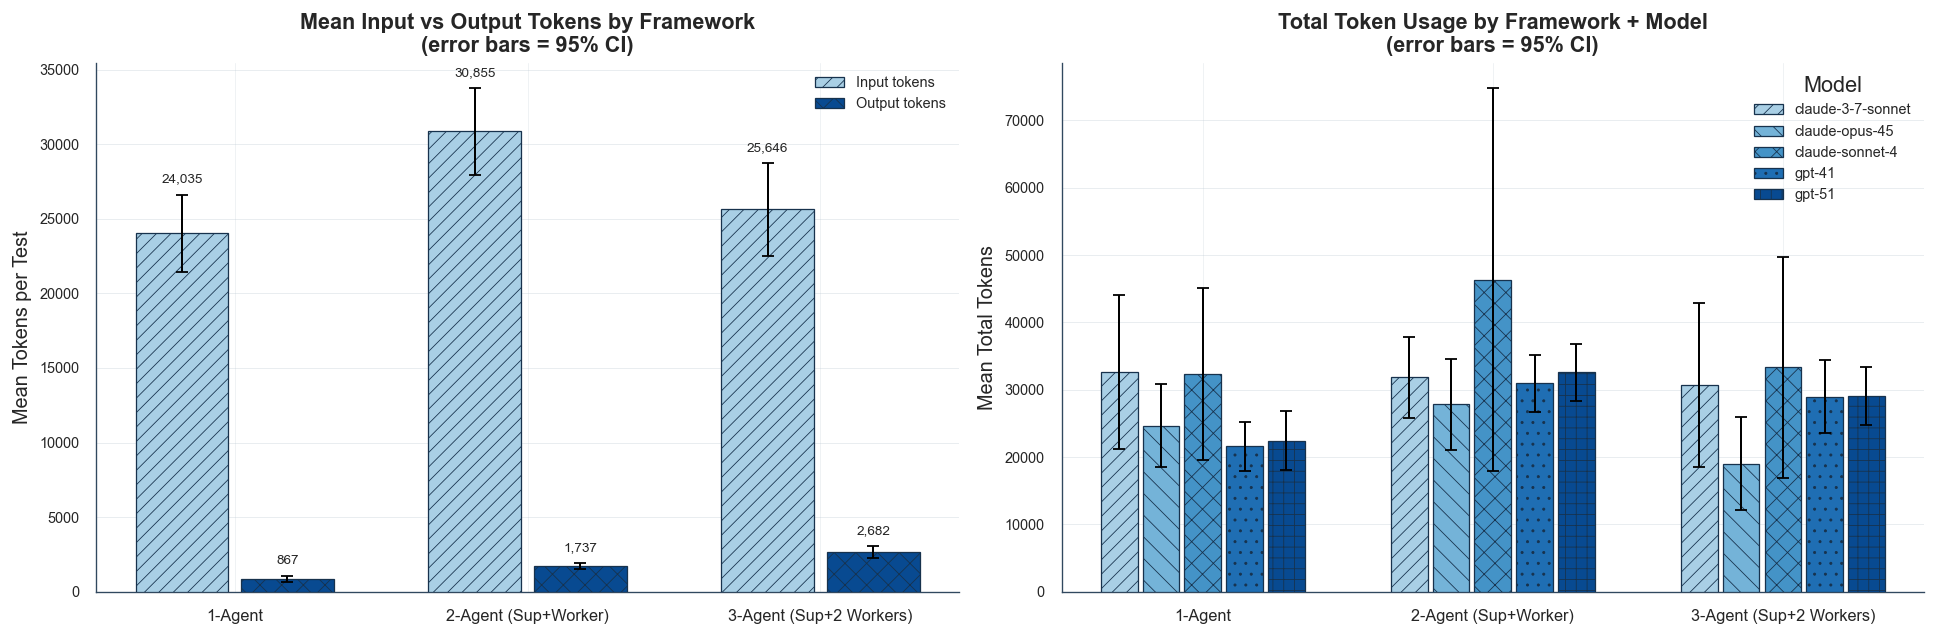

Saved: figures/token_usage.(png|pdf)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

io_long = df.melt(id_vars=["framework"], value_vars=["input_tokens", "output_tokens"],
                   var_name="token_type", value_name="tokens")
io_long["token_type"] = io_long["token_type"].map({"input_tokens": "Input tokens", "output_tokens": "Output tokens"})
io_summary = ae.summarize_with_ci(io_long, ["framework", "token_type"], "tokens", kind="mean")
io_colors = ae.get_categorical_colors(["Input tokens", "Output tokens"], palette=ae.BLUE_CMAP)
io_hatches = {"Input tokens": "///", "Output tokens": "xx"}
ae.plot_grouped_bars(axes[0], io_summary, category_col="framework", group_col="token_type",
                      category_order=FW_ORDER, group_order=["Input tokens", "Output tokens"],
                      color_map=io_colors, hatch_map=io_hatches, bar_label_fmt="{:,.0f}", legend_title=None)
axes[0].set_xticklabels([FRAMEWORK_LABELS.get(fw, fw) for fw in FW_ORDER], fontsize=9)
axes[0].set_ylabel("Mean Tokens per Test", fontsize=11)
axes[0].set_title("Mean Input vs Output Tokens by Framework\n(error bars = 95% CI)", fontsize=12)

tok_summary = ae.summarize_with_ci(df, ["framework", "cfg_llm_model"], "total_tokens", kind="mean")
ae.plot_grouped_bars(axes[1], tok_summary, category_col="framework", group_col="cfg_llm_model",
                      category_order=FW_ORDER, group_order=MODELS_PRESENT, color_map=MODEL_COLORS, hatch_map=MODEL_HATCHES,
                      bar_label_fmt=None, legend_title="Model")
axes[1].set_xticklabels([FRAMEWORK_LABELS.get(fw, fw) for fw in FW_ORDER], fontsize=9)
axes[1].set_ylabel("Mean Total Tokens", fontsize=11)
axes[1].set_title("Total Token Usage by Framework + Model\n(error bars = 95% CI)", fontsize=12)

fig.tight_layout()
ae.save_figure(fig, "token_usage", PLOT_DIR)
plt.show()
print(f"Saved: {PLOT_DIR}/token_usage.(png|pdf)")


## 8 — Cost & Efficiency Frontier Analysis

Mean per-test cost by framework × model (95% CI), and two **efficiency frontiers** — cost vs. pass rate, and tokens vs. pass rate — with 2D error bars (x: 95% CI on mean cost/tokens; y: 95% Wilson CI on pass rate) instead of unlabeled point estimates.

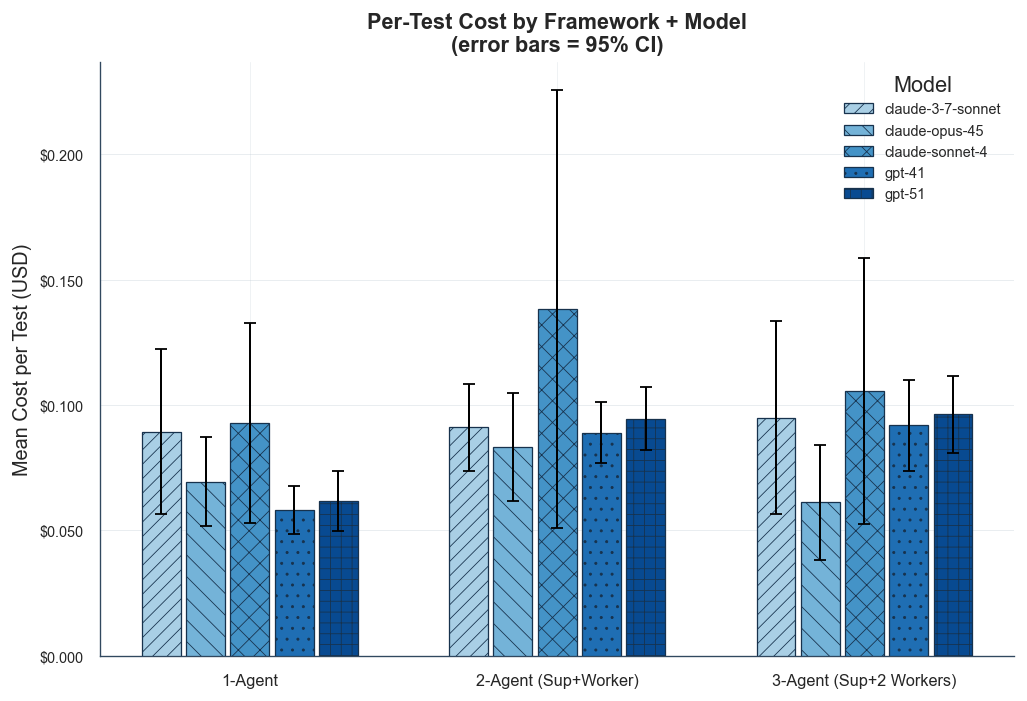

Saved: figures/cost_analysis.(png|pdf)


In [9]:
fig, ax = plt.subplots(figsize=(8, 5.5))
cost_summary = ae.summarize_with_ci(df, ["framework", "cfg_llm_model"], "estimated_cost", kind="mean")
ae.plot_grouped_bars(ax, cost_summary, category_col="framework", group_col="cfg_llm_model",
                      category_order=FW_ORDER, group_order=MODELS_PRESENT, color_map=MODEL_COLORS, hatch_map=MODEL_HATCHES,
                      bar_label_fmt=None, legend_title="Model")
ax.set_xticklabels([FRAMEWORK_LABELS.get(fw, fw) for fw in FW_ORDER], fontsize=9)
ax.set_ylabel("Mean Cost per Test (USD)", fontsize=11)
ax.set_title("Per-Test Cost by Framework + Model\n(error bars = 95% CI)", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.3f"))
fig.tight_layout()
ae.save_figure(fig, "cost_analysis", PLOT_DIR)
plt.show()
print(f"Saved: {PLOT_DIR}/cost_analysis.(png|pdf)")


### Readability update: efficiency frontiers

Framework identity is now encoded by both **blue shade and marker hatch texture**, while LLM identity remains encoded by marker shape. Point labels use opaque white callout boxes with leader lines so they remain readable over error bars and grid lines.

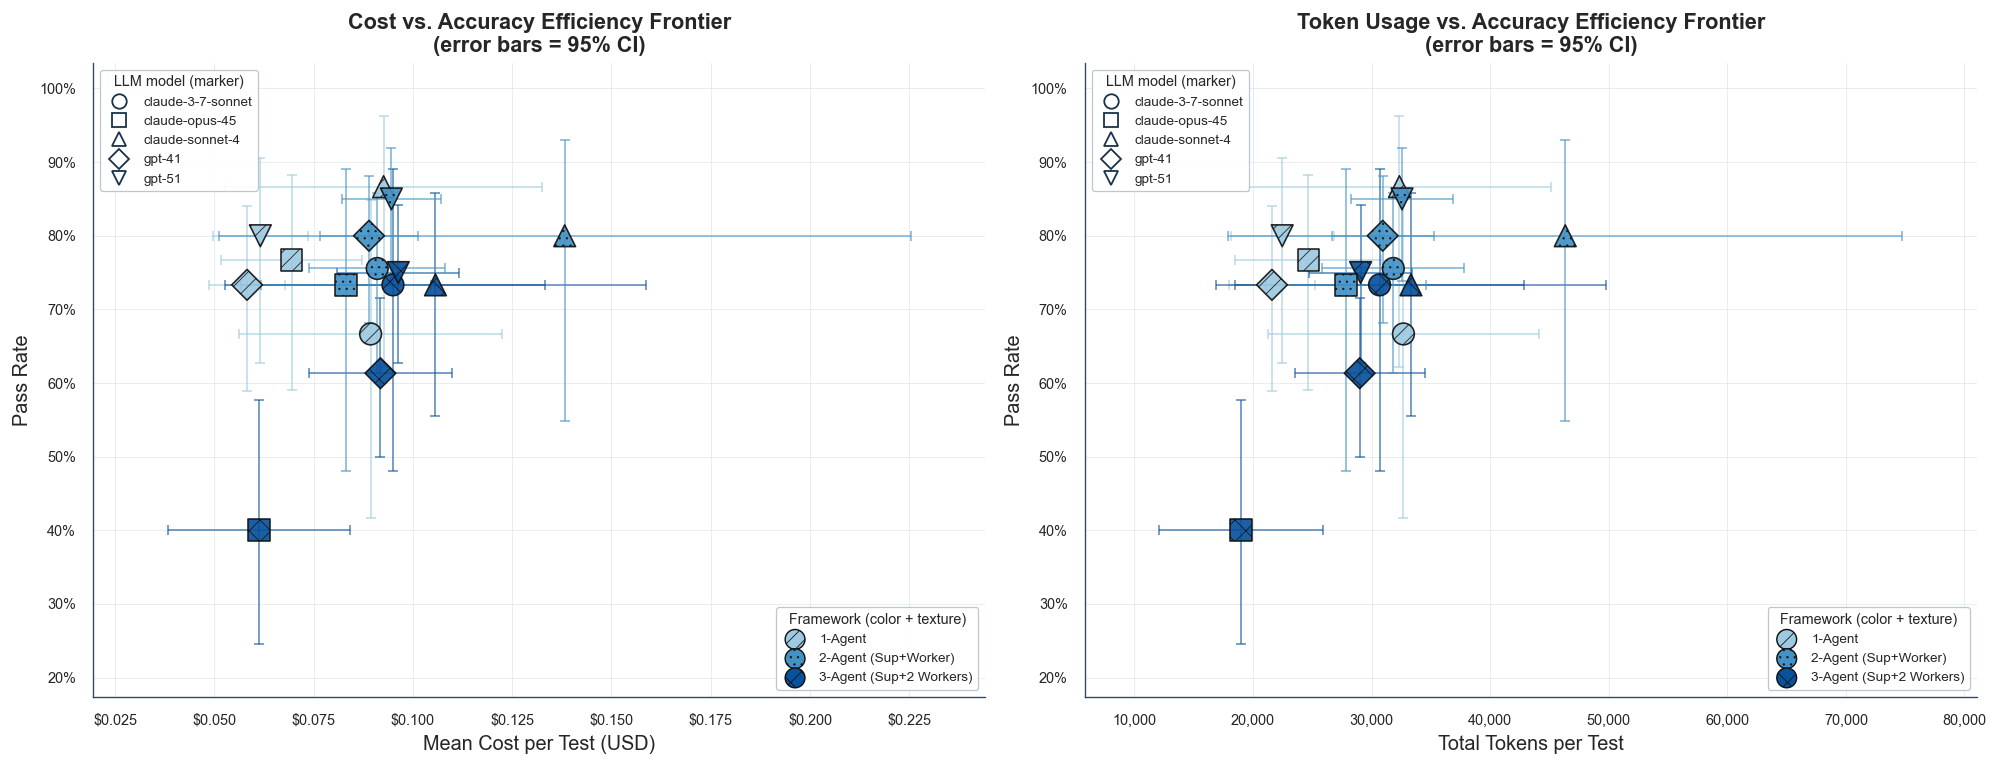

Saved: figures/efficiency_frontiers.(png|pdf)


In [15]:
from matplotlib.lines import Line2D


def _efficiency_frontier(ax, x_col, x_label, x_fmt):
    pass_ci = ae.summarize_with_ci(df, ["framework", "cfg_llm_model"], "passed_int", kind="wilson")
    x_ci = ae.summarize_with_ci(df, ["framework", "cfg_llm_model"], x_col, kind="mean")
    eff = pass_ci.merge(x_ci, on=["framework", "cfg_llm_model"], suffixes=("_pass", "_x"))

    # Alternating offsets give labels a useful initial separation even when
    # adjustText is not installed.
    offsets = [(9, 8), (9, -12), (-9, 8), (-9, -12), (12, 18), (12, -22)]
    texts = []
    for point_i, (_, row) in enumerate(eff.iterrows()):
        fw, model = str(row["framework"]), str(row["cfg_llm_model"])
        xerr = [[row["estimate_x"] - row["ci_low_x"]], [row["ci_high_x"] - row["estimate_x"]]]
        yerr = [[row["estimate_pass"] - row["ci_low_pass"]], [row["ci_high_pass"] - row["estimate_pass"]]]

        ae.errorbar_scatter(
            ax,
            [row["estimate_x"]],
            [row["estimate_pass"]],
            xerr=xerr,
            yerr=yerr,
            color=FRAMEWORK_COLORS.get(fw, "gray"),
            marker=MODEL_MARKERS.get(model, "o"),
            hatch=FRAMEWORK_MARKER_HATCHES.get(fw, ""),
            edgecolor="#111111",
            linewidth=0.9,
            s=145,
            alpha=0.92,
        )

        dx, dy = offsets[point_i % len(offsets)]
        short_framework = FRAMEWORK_LABELS.get(fw, fw).split(" (")[0]
        # texts.append(
        #     ax.annotate(
        #         f"{model} / {short_framework}",
        #         xy=(row["estimate_x"], row["estimate_pass"]),
        #         xytext=(dx, dy),
        #         textcoords="offset points",
        #         ha="left" if dx > 0 else "right",
        #         va="center",
        #         fontsize=7.1,
        #         fontweight="semibold",
        #         color="#1A1A1A",
        #         bbox=dict(
        #             boxstyle="round,pad=0.22",
        #             facecolor="white",
        #             edgecolor=ae.BLUE_EDGE_COLOR,
        #             linewidth=0.5,
        #             alpha=0.94,
        #         ),
        #         arrowprops=dict(
        #             arrowstyle="-",
        #             color="#666666",
        #             linewidth=0.5,
        #             alpha=0.75,
        #             shrinkA=1,
        #             shrinkB=3,
        #         ),
        #         annotation_clip=True,
        #         zorder=8,
        #     )
        # )

    # Constrain any automatic label adjustment so text stays close to its point
    # and inside the plotting region.
    # try:
    #     from adjustText import adjust_text

    #     adjust_text(
    #         texts,
    #         ax=ax,
    #         ensure_inside_axes=True,
    #         max_move=(18, 14),
    #         expand=(1.05, 1.15),
    #         force_text=(0.10, 0.18),
    #     )
    # except Exception:
    #     pass

    # Framework is encoded redundantly by blue shade + hatch texture; model is
    # encoded by marker shape. Two legends make both channels explicit.
    fw_handles = [
        ax.scatter(
            [], [], s=120, marker="o",
            facecolor=FRAMEWORK_COLORS.get(fw, "gray"),
            edgecolor="#111111",
            linewidth=0.8,
            hatch=FRAMEWORK_MARKER_HATCHES.get(fw, ""),
            label=FRAMEWORK_LABELS.get(fw, fw),
        )
        for fw in FW_ORDER
    ]
    model_handles = [
        Line2D(
            [0], [0], linestyle="none",
            marker=MODEL_MARKERS.get(model, "o"),
            markerfacecolor="white",
            markeredgecolor=ae.BLUE_EDGE_COLOR,
            markeredgewidth=1.0,
            markersize=8,
            label=str(model),
        )
        for model in MODELS_PRESENT
    ]

    framework_legend = ax.legend(
        handles=fw_handles,
        title="Framework (color + texture)",
        fontsize=7.5,
        title_fontsize=8,
        loc="lower right",
        frameon=True,
        framealpha=0.94,
    )
    ax.add_artist(framework_legend)
    ax.legend(
        handles=model_handles,
        title="LLM model (marker)",
        fontsize=7.5,
        title_fontsize=8,
        loc="upper left",
        frameon=True,
        framealpha=0.94,
    )

    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel("Pass Rate", fontsize=11)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.xaxis.set_major_formatter(x_fmt)
    ax.yaxis.grid(True, alpha=0.3)
    ax.xaxis.grid(True, alpha=0.3)
    ax.margins(x=0.10, y=0.10)


fig, axes = plt.subplots(1, 2, figsize=(15.5, 6.0))
_efficiency_frontier(axes[0], "estimated_cost", "Mean Cost per Test (USD)", mticker.FormatStrFormatter("$%.3f"))
axes[0].set_title("Cost vs. Accuracy Efficiency Frontier\n(error bars = 95% CI)", fontsize=12)
_efficiency_frontier(axes[1], "total_tokens", "Total Tokens per Test", mticker.StrMethodFormatter("{x:,.0f}"))
axes[1].set_title("Token Usage vs. Accuracy Efficiency Frontier\n(error bars = 95% CI)", fontsize=12)
fig.tight_layout()
ae.save_figure(fig, "efficiency_frontiers", PLOT_DIR)
plt.show()
print(f"Saved: {PLOT_DIR}/efficiency_frontiers.(png|pdf)")


## 9 — LLM & Tool Call Counts

More agents often mean more LLM calls (routing, delegation, synthesis). Excessive tool calls may indicate loops or confusion in a framework. Bars are mean calls per test, split by pass/fail, with 95% CIs.

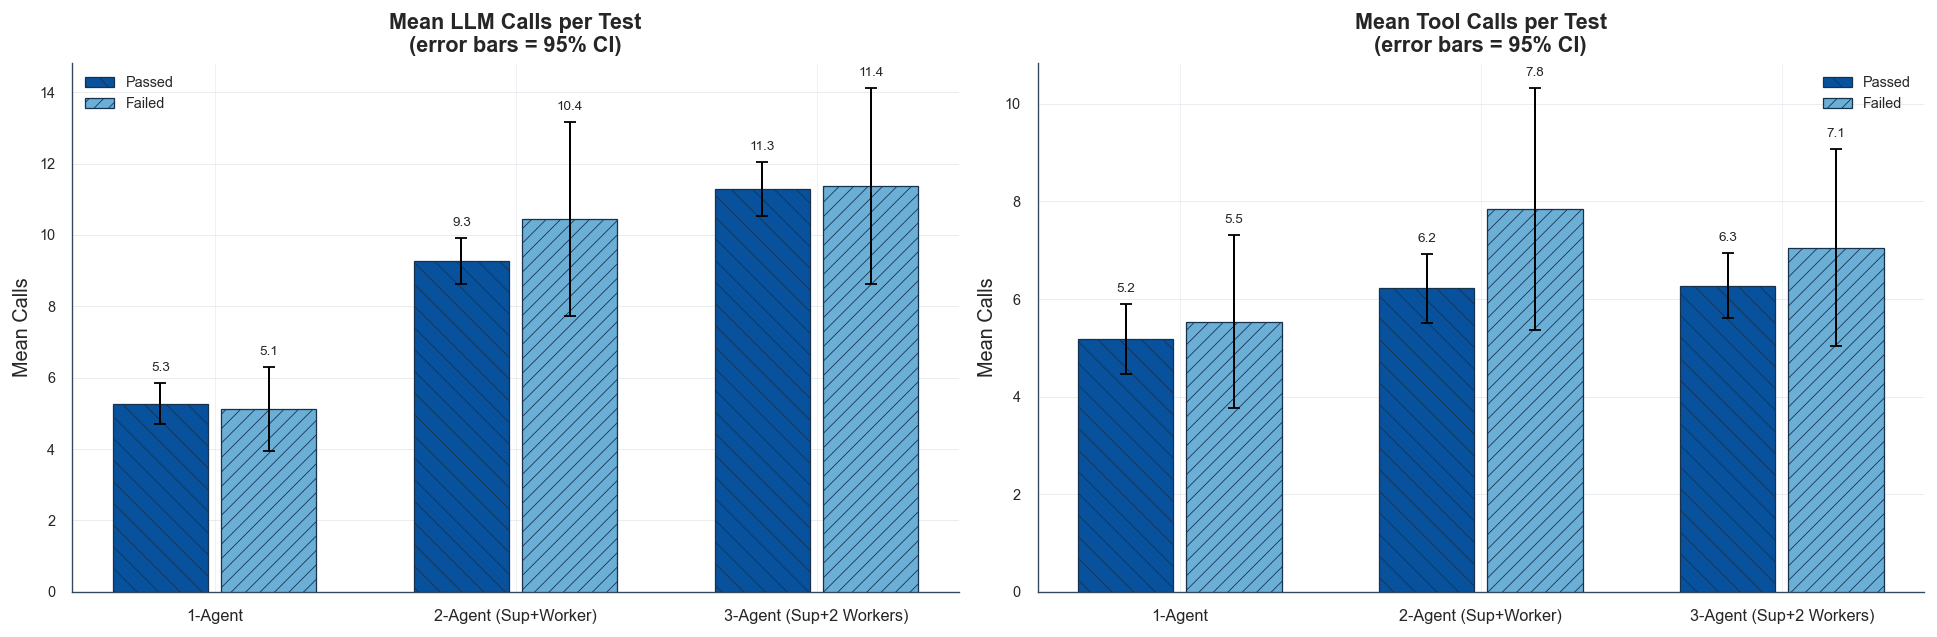

Saved: figures/call_counts.(png|pdf)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df["passed_label"] = df["passed"].map({True: "Passed", False: "Failed"})

for ax, col, title in zip(axes, ["llm_calls", "tool_calls"], ["Mean LLM Calls per Test", "Mean Tool Calls per Test"]):
    calls_summary = ae.summarize_with_ci(df, ["framework", "passed_label"], col, kind="mean")
    ae.plot_grouped_bars(ax, calls_summary, category_col="framework", group_col="passed_label",
                          category_order=FW_ORDER, group_order=["Passed", "Failed"],
                          color_map={"Passed": PASS_COLOR, "Failed": FAIL_COLOR},
                          bar_label_fmt="{:.1f}", legend_title=None)
    ax.set_xticklabels([FRAMEWORK_LABELS.get(fw, fw) for fw in FW_ORDER], fontsize=9)
    ax.set_ylabel("Mean Calls", fontsize=11)
    ax.set_title(f"{title}\n(error bars = 95% CI)", fontsize=12)

fig.tight_layout()
ae.save_figure(fig, "call_counts", PLOT_DIR)
plt.show()
print(f"Saved: {PLOT_DIR}/call_counts.(png|pdf)")


## 10 — RAG Retrieval Impact Analysis

Three angles:
1. **Retrieval count vs pass rate** — does retrieving more context help or hurt? (binned means with 95% Wilson CI per bin)
2. **Per-entry pass rate by framework** — which entries are problematic in which architecture?
3. **RAG latency by agent role** — which agent spends the most time on retrieval? (mean ± 95% CI)

c:\Users\M6NJOHNS\OneDrive - Carl Zeiss AG\Documents\September Platform\XRM\september_testing_results\agent_eval_core_master_updated.py:1968: RuntimeWarning: divide by zero encountered in divide
  denom = 1 + z * z / n
c:\Users\M6NJOHNS\OneDrive - Carl Zeiss AG\Documents\September Platform\XRM\september_testing_results\agent_eval_core_master_updated.py:1969: RuntimeWarning: divide by zero encountered in divide
  center = (p + z * z / (2 * n)) / denom
c:\Users\M6NJOHNS\OneDrive - Carl Zeiss AG\Documents\September Platform\XRM\september_testing_results\agent_eval_core_master_updated.py:1969: RuntimeWarning: invalid value encountered in divide
  center = (p + z * z / (2 * n)) / denom
c:\Users\M6NJOHNS\OneDrive - Carl Zeiss AG\Documents\September Platform\XRM\september_testing_results\agent_eval_core_master_updated.py:1970: RuntimeWarning: divide by zero encountered in divide
  half = (z * np.sqrt((p * (1 - p) + z * z / (4 * n)) / n)) / denom
c:\Users\M6NJOHNS\OneDrive - Carl Zeiss AG\Docu

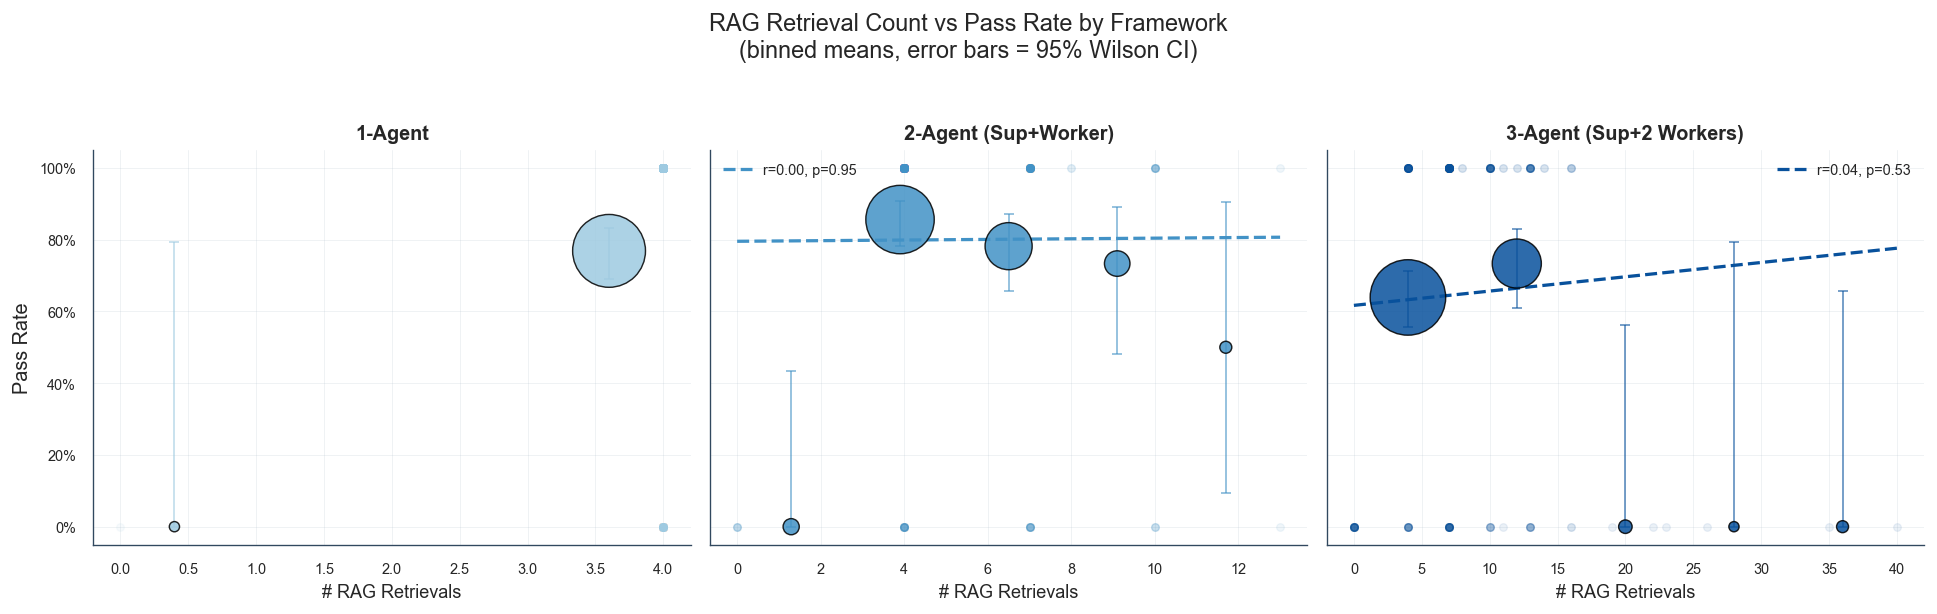

Saved: figures/rag_count_vs_passrate.(png|pdf)


In [ ]:
if "num_rag_retrievals" in df.columns:
    fig, axes = plt.subplots(1, len(FW_ORDER), figsize=(5 * len(FW_ORDER), 4.5), sharey=True)
    if len(FW_ORDER) == 1:
        axes = [axes]
    for ax, fw in zip(axes, FW_ORDER):
        sub = df.loc[df["framework"] == fw, ["num_rag_retrievals", "passed_int"]].dropna()
        if sub.empty:
            continue
        sub = sub.copy()
        sub["rag_bin"] = pd.cut(sub["num_rag_retrievals"], bins=5)
        bin_ci = ae.summarize_with_ci(sub, ["rag_bin"], "passed_int", kind="wilson")
        bin_ci["mid"] = bin_ci["rag_bin"].apply(lambda b: b.mid if pd.notna(b) else np.nan)
        bin_ci = bin_ci.dropna(subset=["mid"])

        ax.scatter(sub["num_rag_retrievals"], sub["passed_int"], alpha=0.08,
                   color=FRAMEWORK_COLORS.get(fw, "steelblue"), s=18, zorder=2)
        yerr = ae._ci_to_yerr(bin_ci["estimate"], bin_ci["ci_low"], bin_ci["ci_high"])
        ae.errorbar_scatter(ax, bin_ci["mid"], bin_ci["estimate"], yerr=yerr,
                             color=FRAMEWORK_COLORS.get(fw, "steelblue"),
                             s=20 + 12 * bin_ci["n"], alpha=0.85)
        if sub["num_rag_retrievals"].nunique() > 2:
            slope, intercept, r, p, _ = stats.linregress(sub["num_rag_retrievals"], sub["passed_int"])
            xr = np.linspace(sub["num_rag_retrievals"].min(), sub["num_rag_retrievals"].max(), 50)
            ax.plot(xr, intercept + slope * xr, "--", color=FRAMEWORK_COLORS.get(fw, "steelblue"),
                    linewidth=1.8, label=f"r={r:.2f}, p={p:.2f}")
            ax.legend(fontsize=8, frameon=False)
        ax.set_title(FRAMEWORK_LABELS.get(fw, fw), fontsize=11)
        ax.set_xlabel("# RAG Retrievals", fontsize=10)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    axes[0].set_ylabel("Pass Rate", fontsize=11)
    fig.suptitle("RAG Retrieval Count vs Pass Rate by Framework\n(binned means, error bars = 95% Wilson CI)",
                 fontsize=13, y=1.04)
    fig.tight_layout()
    ae.save_figure(fig, "rag_count_vs_passrate", PLOT_DIR)
    plt.show()
    print(f"Saved: {PLOT_DIR}/rag_count_vs_passrate.(png|pdf)")


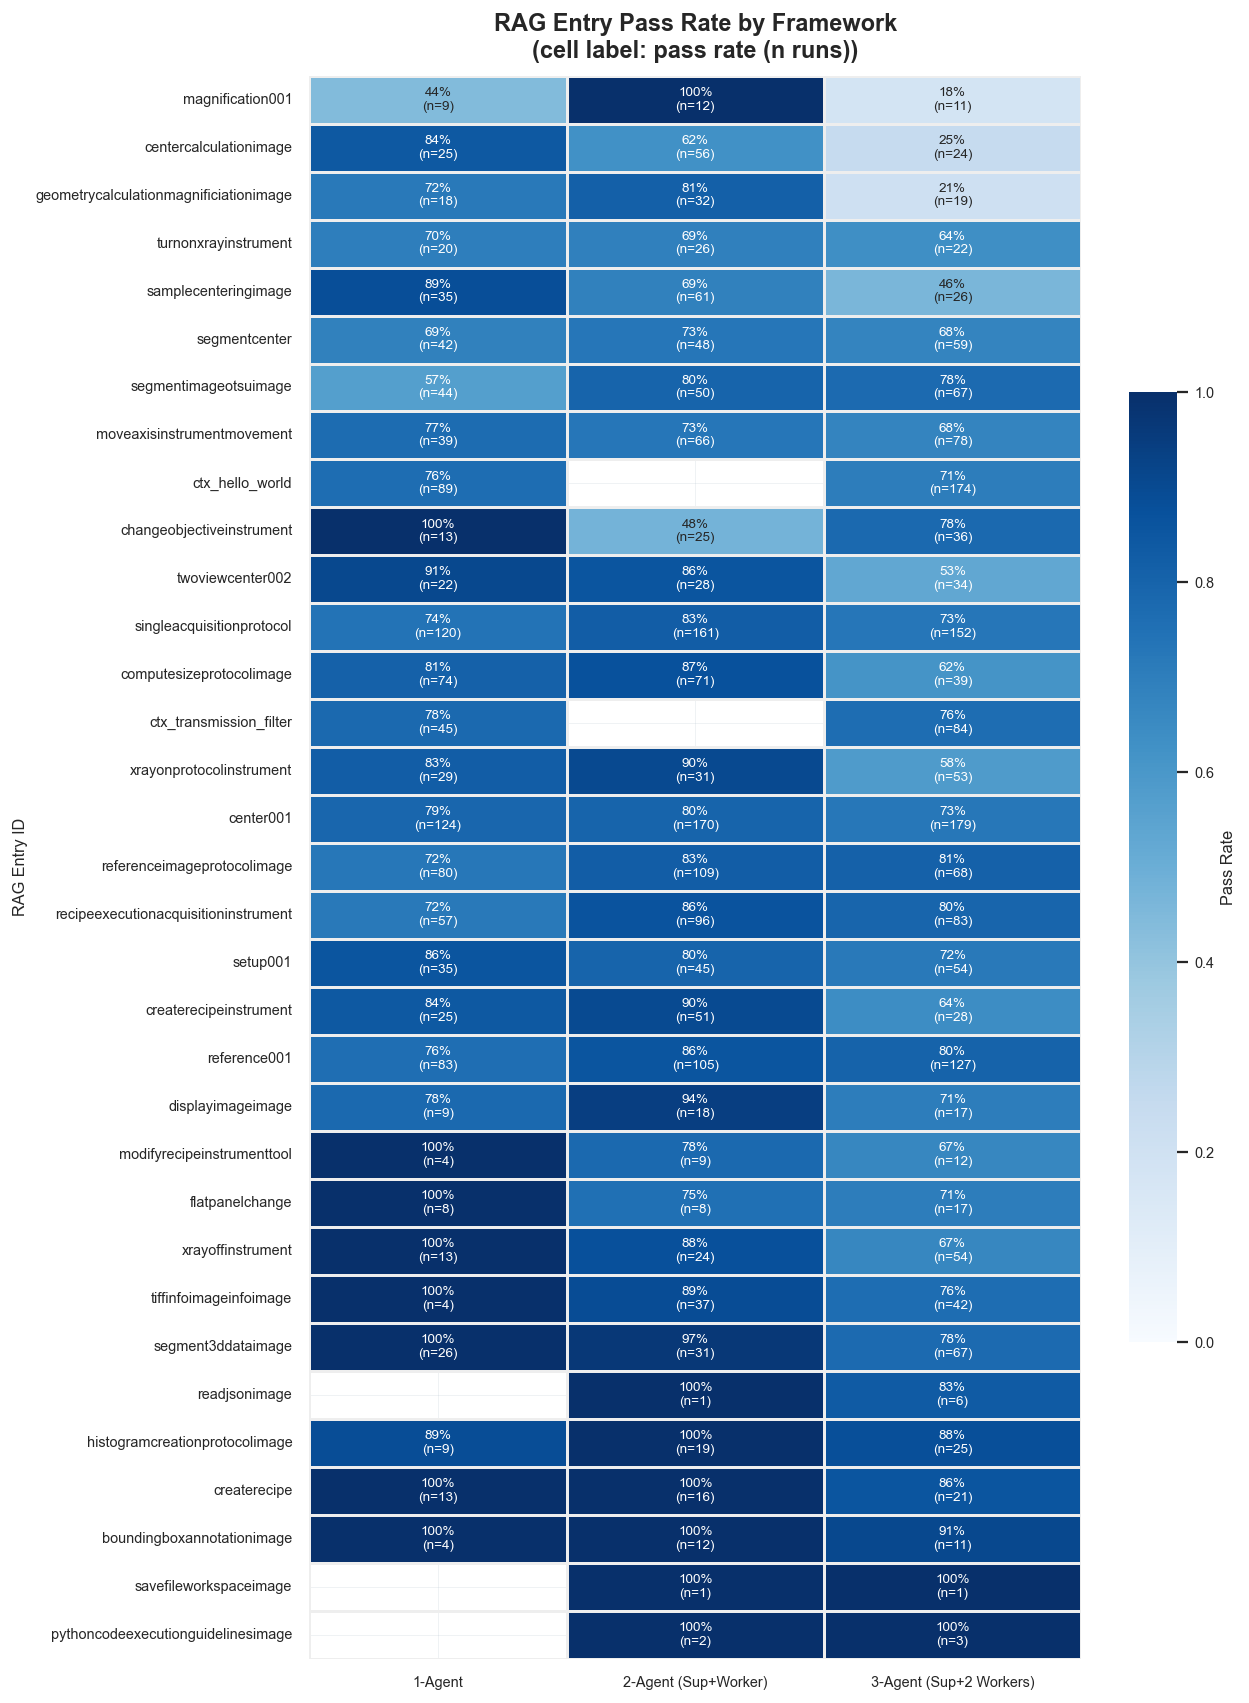

Saved: figures/rag_entry_passrate_by_framework.(png|pdf)


In [13]:
import seaborn as sns

if "rag_entry_ids" in df.columns:
    explode_rows = []
    for _, row in df.iterrows():
        for eid in (row["rag_entry_ids"] or []):
            explode_rows.append({"entry_id": eid, "framework": row["framework"], "passed_int": row["passed_int"], "test_id": row["test_id"]})
    edf = pd.DataFrame(explode_rows)
    edf = edf[edf["entry_id"] != ""]

    pivot_entry = edf.groupby(["entry_id", "framework"])["passed_int"].mean().reset_index().pivot_table(
        index="entry_id", columns="framework", values="passed_int", aggfunc="mean")
    n_entry = edf.groupby(["entry_id", "framework"])["passed_int"].count().reset_index().pivot_table(
        index="entry_id", columns="framework", values="passed_int", aggfunc="sum")
    pivot_entry = pivot_entry.loc[pivot_entry.mean(axis=1).sort_values().index]
    n_entry = n_entry.loc[pivot_entry.index]
    cols = [fw for fw in FW_ORDER if fw in pivot_entry.columns]

    n_entries = len(pivot_entry)
    fig, ax = plt.subplots(figsize=(10, max(4, n_entries * 0.4)))
    annot = pivot_entry[cols].copy()
    for c in cols:
        annot[c] = [f"{v:.0%}\n(n={int(n)})" if pd.notna(v) else "—" for v, n in zip(pivot_entry[c], n_entry[c])]
    sns.heatmap(pivot_entry[cols], cmap=ae.BLUE_CMAP, vmin=0, vmax=1, ax=ax, annot=annot, fmt="",
                linewidths=0.6, linecolor="#eee", cbar_kws={"label": "Pass Rate", "shrink": 0.6},
                xticklabels=[FRAMEWORK_LABELS.get(fw, fw) for fw in cols], annot_kws={"fontsize": 7.5})
    ax.set_title("RAG Entry Pass Rate by Framework\n(cell label: pass rate (n runs))", fontsize=13, pad=10)
    ax.set_ylabel("RAG Entry ID"); ax.set_xlabel("")
    fig.tight_layout()
    ae.save_figure(fig, "rag_entry_passrate_by_framework", PLOT_DIR)
    plt.show()
    print(f"Saved: {PLOT_DIR}/rag_entry_passrate_by_framework.(png|pdf)")


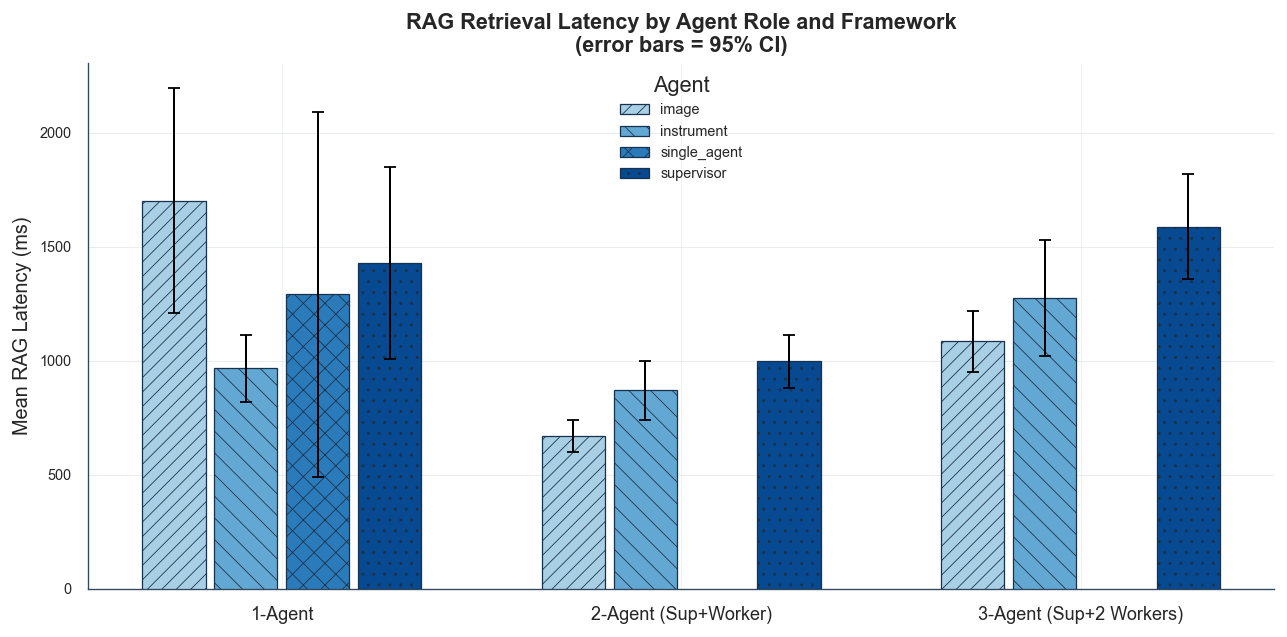

Saved: figures/rag_latency_by_agent.(png|pdf)


In [14]:
if not rag_events.empty and "latency_ms" in rag_events.columns:
    rag_events["latency_ms"] = pd.to_numeric(rag_events["latency_ms"], errors="coerce")
    detail = rag_events.dropna(subset=["latency_ms", "agent"])
    if detail.empty:
        print("No detailed RAG latency data — skipping agent-level plot")
    else:
        lat_summary = ae.summarize_with_ci(detail, ["framework", "agent"], "latency_ms", kind="mean")
        agents_all = sorted(detail["agent"].dropna().unique())
        agent_colors = ae.get_categorical_colors(agents_all, palette=ae.BLUE_CMAP)

        fig, ax = plt.subplots(figsize=(10, 5))
        ae.plot_grouped_bars(ax, lat_summary, category_col="framework", group_col="agent",
                              category_order=FW_ORDER, group_order=agents_all, color_map=agent_colors,
                              bar_label_fmt=None, legend_title="Agent")
        ax.set_xticklabels([FRAMEWORK_LABELS.get(fw, fw) for fw in FW_ORDER], fontsize=10)
        ax.set_ylabel("Mean RAG Latency (ms)", fontsize=11)
        ax.set_title("RAG Retrieval Latency by Agent Role and Framework\n(error bars = 95% CI)", fontsize=12)
        fig.tight_layout()
        ae.save_figure(fig, "rag_latency_by_agent", PLOT_DIR)
        plt.show()
        print(f"Saved: {PLOT_DIR}/rag_latency_by_agent.(png|pdf)")
else:
    print("No detailed RAG latency data — skipping agent-level plot")


## 11 — Framework Diagnostic Radar Chart

Summarizes each framework across 6 dimensions (all normalized so higher = better, i.e. cost and latency are inverted). The bold trace is the across-model mean; the faint traces behind it are the per-model values within that framework, so the spread of the faint lines around the bold one shows how much the framework's profile varies by model — the radar equivalent of an error bar for a chart shape that can't take one directly.

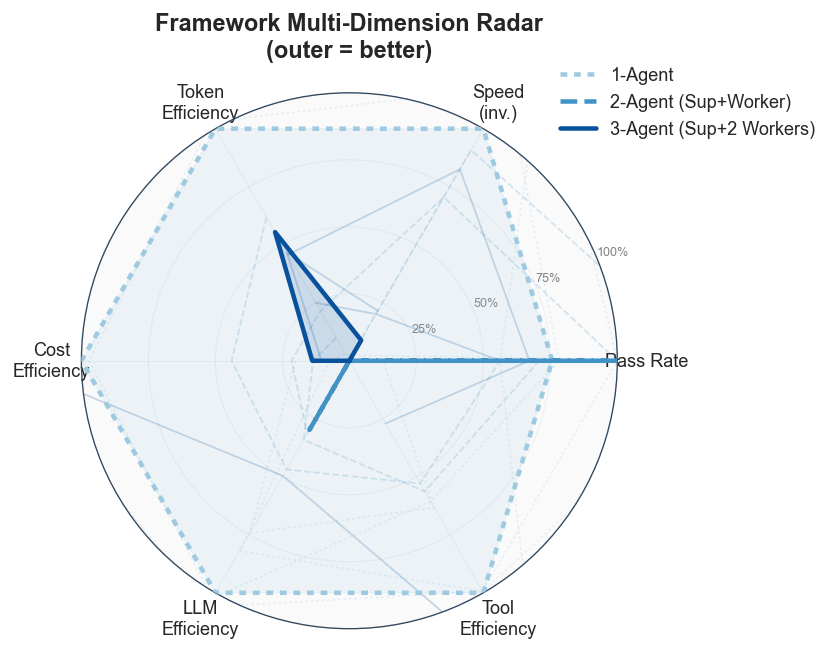

Saved: figures/framework_radar.(png|pdf)


In [15]:
dims = ["pass_rate", "duration_s", "total_tok", "est_cost", "llm_calls", "tool_calls"]
labels_r = ["Pass Rate", "Speed\n(inv.)", "Token\nEfficiency", "Cost\nEfficiency", "LLM\nEfficiency", "Tool\nEfficiency"]
invert = {"duration_s", "total_tok", "est_cost", "llm_calls", "tool_calls"}

def _agg(frame, group_cols):
    return frame.groupby(group_cols).agg(
        pass_rate=("passed_int", "mean"), duration_s=("duration_s", "mean"), total_tok=("total_tokens", "mean"),
        est_cost=("estimated_cost", "mean"), llm_calls=("llm_calls", "mean"), tool_calls=("tool_calls", "mean"),
    ).reset_index()

radar_agg = _agg(df, ["framework"])
radar_by_model = _agg(df, ["framework", "cfg_llm_model"])

def _normalize(frame):
    out = frame.copy()
    for dim in dims:
        mn, mx = radar_agg[dim].min(), radar_agg[dim].max()  # normalize against the FRAMEWORK-level range for comparability
        if mx == mn:
            out[dim] = 0.5
        elif dim in invert:
            out[dim] = 1 - (frame[dim] - mn) / (mx - mn)
        else:
            out[dim] = (frame[dim] - mn) / (mx - mn)
    return out

radar_norm = _normalize(radar_agg)
radar_by_model_norm = _normalize(radar_by_model)

N = len(dims)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"polar": True})
ax.set_facecolor("#fafafa")

for _, row in radar_by_model_norm.iterrows():
    fw = row["framework"]
    vals = [row[d] for d in dims] + [row[dims[0]]]
    ax.plot(angles, vals, linewidth=1, linestyle=FRAMEWORK_LINESTYLES.get(fw, "-"), color=FRAMEWORK_COLORS.get(fw, "#9ECAE1"), alpha=0.22, zorder=2)

for _, row in radar_norm.iterrows():
    fw = row["framework"]
    vals = [row[d] for d in dims] + [row[dims[0]]]
    color = FRAMEWORK_COLORS.get(fw, "#9ECAE1")
    ax.plot(angles, vals, linewidth=2.5, linestyle=FRAMEWORK_LINESTYLES.get(fw, "-"), color=color, label=FRAMEWORK_LABELS.get(fw, fw), zorder=4)
    ax.fill(angles, vals, alpha=0.15, color=color, zorder=3)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_r, size=10)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], size=7, color="gray")
ax.set_ylim(0, 1)
ax.set_title("Framework Multi-Dimension Radar\n(outer = better)", fontsize=13, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.08), fontsize=10, frameon=False)
fig.tight_layout()
ae.save_figure(fig, "framework_radar", PLOT_DIR)
plt.show()
print(f"Saved: {PLOT_DIR}/framework_radar.(png|pdf)")


## 12 — Per-Test Regression: Which Tests Drive Framework Differences?

For each test, the pass-rate *delta* between the best and worst framework. Tests with the largest deltas are where architectural differences matter most. Error bars propagate the Wilson-CI uncertainty of the best and worst framework's pass rate into the delta ($\mathrm{SE}_\Delta = \sqrt{\mathrm{SE}_\mathrm{best}^2 + \mathrm{SE}_\mathrm{worst}^2}$).

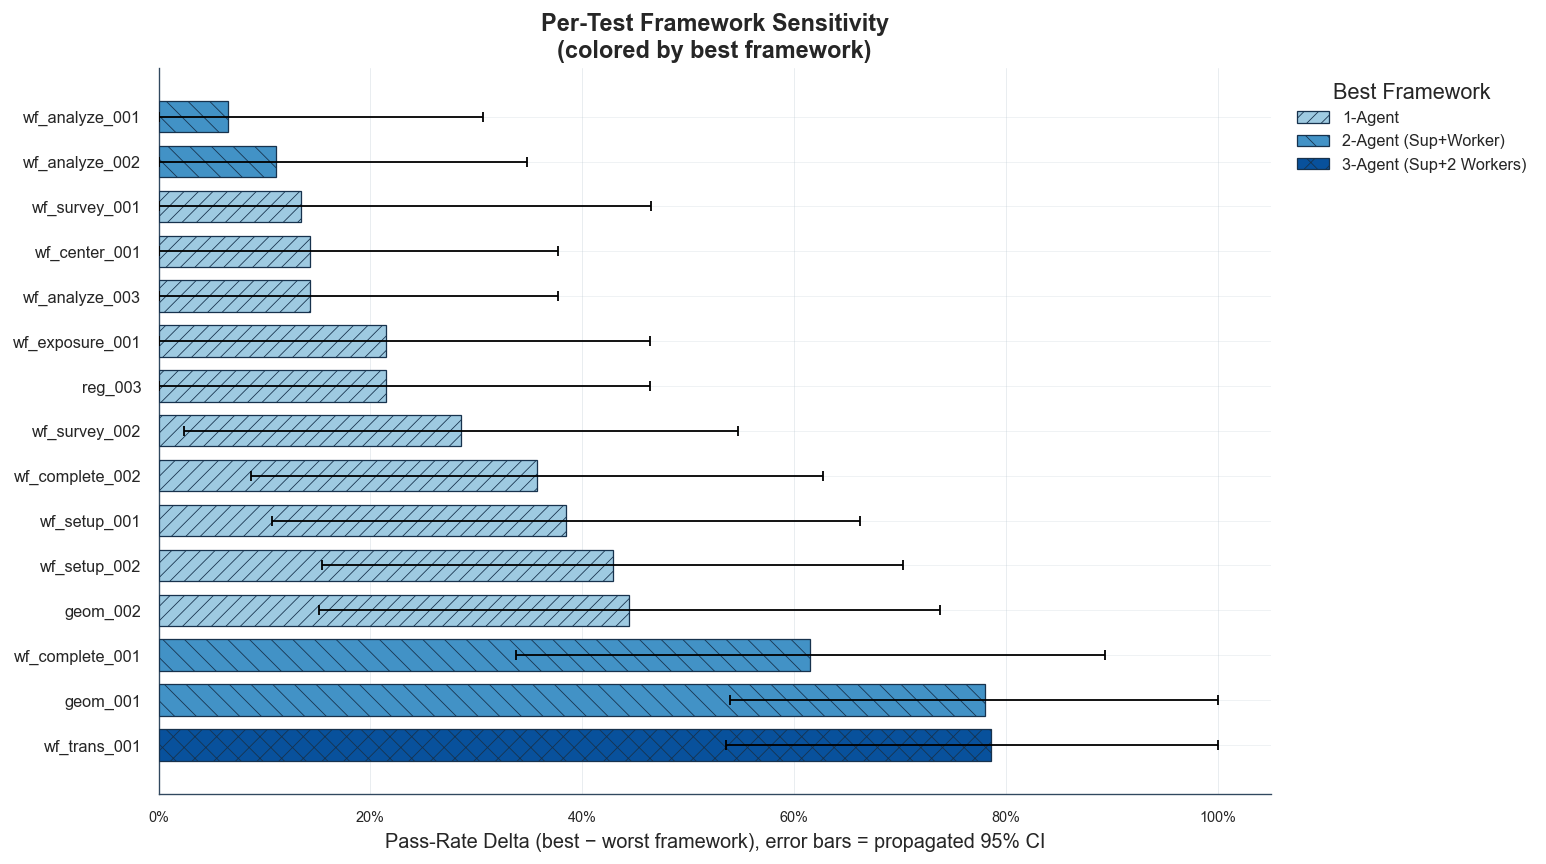

Saved: figures/per_test_framework_sensitivity.(png|pdf)


In [16]:
test_fw = df.groupby(["test_id", "framework"])["passed_int"].agg(["mean", "sum", "count"]).reset_index()
test_fw_wide = test_fw.pivot(index="test_id", columns="framework", values="mean").reindex(columns=FW_ORDER)

if test_fw_wide.shape[1] >= 2:
    best_fw = test_fw_wide.idxmax(axis=1)
    worst_fw = test_fw_wide.idxmin(axis=1)
    delta = (test_fw_wide.max(axis=1) - test_fw_wide.min(axis=1)).rename("delta")

    n_by_test_fw = test_fw.pivot(index="test_id", columns="framework", values="count")
    k_by_test_fw = test_fw.pivot(index="test_id", columns="framework", values="sum")

    se_rows = []
    for tid in test_fw_wide.index:
        b, w = best_fw[tid], worst_fw[tid]
        kb, nb = k_by_test_fw.loc[tid, b], n_by_test_fw.loc[tid, b]
        kw, nw = k_by_test_fw.loc[tid, w], n_by_test_fw.loc[tid, w]
        lo_b, hi_b = ae.wilson_interval(np.array([kb]), np.array([nb]))
        lo_w, hi_w = ae.wilson_interval(np.array([kw]), np.array([nw]))
        se_b = (hi_b[0] - lo_b[0]) / (2 * 1.96) if np.isfinite(hi_b[0]) else 0.0
        se_w = (hi_w[0] - lo_w[0]) / (2 * 1.96) if np.isfinite(hi_w[0]) else 0.0
        se_rows.append(np.sqrt(se_b**2 + se_w**2))

    sens = pd.DataFrame({"delta": delta, "best_fw": best_fw, "se_delta": se_rows}, index=test_fw_wide.index)
    sens = sens.sort_values("delta", ascending=False)
    sens["ci_low"] = (sens["delta"] - 1.96 * sens["se_delta"]).clip(lower=0)
    sens["ci_high"] = (sens["delta"] + 1.96 * sens["se_delta"]).clip(upper=1)

    fig, ax = plt.subplots(figsize=(12, max(5, len(sens) * 0.45)))
    y_pos = np.arange(len(sens))
    bar_colors = [FRAMEWORK_COLORS.get(fw, "gray") for fw in sens["best_fw"]]
    xerr = ae._ci_to_yerr(sens["delta"], sens["ci_low"], sens["ci_high"])
    bars = ax.barh(y_pos, sens["delta"], color=bar_colors, edgecolor=ae.BLUE_EDGE_COLOR, linewidth=0.70, height=0.7, zorder=3)
    for patch, fw in zip(bars.patches, sens["best_fw"]):
        patch.set_hatch(FRAMEWORK_HATCHES.get(str(fw), "///"))
    ax.errorbar(sens["delta"], y_pos, xerr=xerr, fmt="none", color="black", capsize=3, linewidth=1.0, zorder=4)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sens.index, fontsize=9)
    ax.set_xlabel("Pass-Rate Delta (best − worst framework), error bars = propagated 95% CI", fontsize=11)
    ax.set_title("Per-Test Framework Sensitivity\n(colored by best framework)", fontsize=13)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.xaxis.grid(True, alpha=0.3)

    legend_patches = ae.make_legend_patches(FW_ORDER, labels=FRAMEWORK_LABELS, color_map=FRAMEWORK_COLORS, hatch_map=FRAMEWORK_HATCHES)
    ax.legend(handles=legend_patches, title="Best Framework", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9, frameon=False)
    fig.tight_layout()
    ae.save_figure(fig, "per_test_framework_sensitivity", PLOT_DIR)
    plt.show()
    print(f"Saved: {PLOT_DIR}/per_test_framework_sensitivity.(png|pdf)")


## 13 — Summary Decision Table

Pass rate is shown with its 95% Wilson CI half-width so the table carries the same uncertainty information as the charts above.

In [17]:
pass_ci = ae.summarize_with_ci(df, ["framework", "cfg_llm_model"], "passed_int", kind="wilson")
summary = (
    df.groupby(["framework", "cfg_llm_model"])
    .agg(n_tests=("test_id", "count"), mean_duration_s=("duration_s", "mean"), mean_tokens=("total_tokens", "mean"),
         total_cost_usd=("estimated_cost", "sum"), mean_llm_calls=("llm_calls", "mean"), mean_tool_calls=("tool_calls", "mean"))
    .reset_index()
    .merge(pass_ci[["framework", "cfg_llm_model", "estimate", "ci_low", "ci_high"]], on=["framework", "cfg_llm_model"])
    .rename(columns={"estimate": "pass_rate"})
)
summary["pass_rate_ci_halfwidth"] = (summary["ci_high"] - summary["ci_low"]) / 2
summary["framework_label"] = summary["framework"].map(FRAMEWORK_LABELS)
summary = summary.sort_values(["pass_rate", "total_cost_usd"], ascending=[False, True])

display_cols = {
    "framework_label": "Framework", "cfg_llm_model": "Model", "pass_rate": "Pass Rate",
    "pass_rate_ci_halfwidth": "± (95% CI)", "n_tests": "N Tests", "mean_duration_s": "Avg Latency (s)",
    "mean_tokens": "Avg Tokens", "total_cost_usd": "Total Cost", "mean_llm_calls": "Avg LLM Calls", "mean_tool_calls": "Avg Tool Calls",
}
out = summary[list(display_cols.keys())].rename(columns=display_cols)
try:
    display(out.style.format({
        "Pass Rate": "{:.1%}", "± (95% CI)": "±{:.1%}", "Avg Latency (s)": "{:.1f}",
        "Avg Tokens": "{:,.0f}", "Total Cost": "${:.3f}", "Avg LLM Calls": "{:.1f}", "Avg Tool Calls": "{:.1f}",
    }).background_gradient(subset=["Pass Rate"], cmap=ae.BLUE_CMAP))
except Exception:
    print(out.to_string(index=False))
out.to_csv(PLOT_DIR / "framework_summary_table.csv", index=False)
print(f"Saved: {PLOT_DIR}/framework_summary_table.csv")


,Framework,Model,Pass Rate,± (95% CI),N Tests,Avg Latency (s),Avg Tokens,Total Cost,Avg LLM Calls,Avg Tool Calls
2,1-Agent,claude-sonnet-4,86.7%,±17.1%,15,146.4,"32,348",$1.389,6.3,5.3
9,2-Agent (Sup+Worker),gpt-51,85.0%,±9.0%,60,85.7,"32,569",$5.675,9.3,6.7
4,1-Agent,gpt-51,80.0%,±13.9%,30,50.9,"22,464",$1.848,4.9,5.3
7,2-Agent (Sup+Worker),claude-sonnet-4,80.0%,±19.1%,15,187.4,"46,332",$2.073,12.3,8.1
8,2-Agent (Sup+Worker),gpt-41,80.0%,±10.0%,60,99.7,"30,940",$5.337,9.4,6.8
1,1-Agent,claude-opus-45,76.7%,±14.6%,30,67.1,"24,678",$2.084,5.1,5.8
5,2-Agent (Sup+Worker),claude-3-7-sonnet,75.6%,±12.2%,45,279.7,"31,830",$4.096,9.2,5.8
14,3-Agent (Sup+2 Workers),gpt-51,75.0%,±10.7%,60,91.4,"29,075",$5.779,11.4,6.2
6,2-Agent (Sup+Worker),claude-opus-45,73.3%,±20.5%,15,156.3,"27,833",$1.248,8.5,5.9
10,3-Agent (Sup+2 Workers),claude-3-7-sonnet,73.3%,±20.5%,15,134.3,"30,674",$1.425,12.5,7.6


Saved: figures/framework_summary_table.csv
